# Versuch 3

## Aufgabe 3.1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import windows
from pathlib import Path
import glob

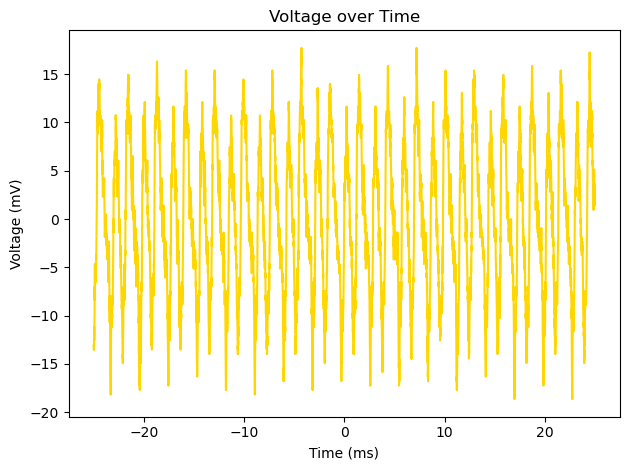

M (Anzahl Abtastpunkte): 10004
Signaldauer: 50.01


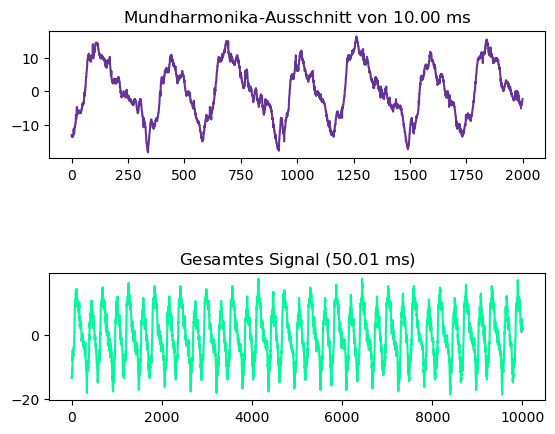

In [2]:
df = pd.read_csv("Versuch3-1_harmonica/sound_harmonique-style.csv", delimiter=";", decimal=",", skiprows=[1])
plt.plot(df["Zeit"], df["Kanal A"], color="gold")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Voltage over Time")
plt.tight_layout()
plt.show()
v = df["Kanal A"].values
N = len(v)

def dt(x): return df["Zeit"][x] - df["Zeit"][0]
def dts(x): return dt(x) / 1000 # Convert to time

print(f"M (Anzahl Abtastpunkte): {v.size}") # Anzahl Abtastpunkte
print(f"Signaldauer: {(dt(v.size - 1)):.2f}")

fig, axs = plt.subplots(2)
axs[0].plot(v[0:2000], color="rebeccapurple")
axs[0].set_title(f"Mundharmonika-Ausschnitt von ${(dt(2000)):.2f}$ ms")
axs[1].plot(v, color="mediumspringgreen")
axs[1].set_title(f"Gesamtes Signal (${dt(v.size - 1):.2f}$ ms)") # Signaldauer
plt.subplots_adjust(hspace=0.9)
plt.show()

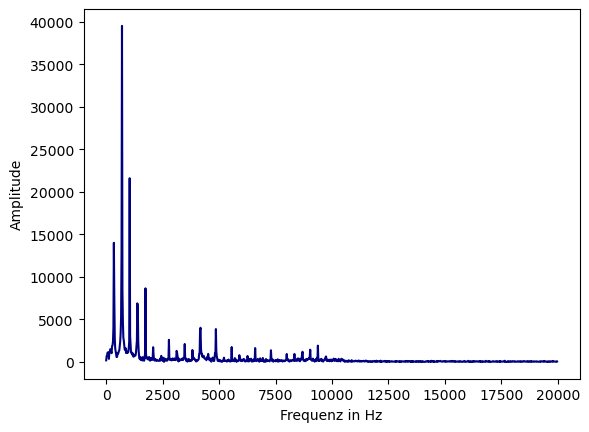

Größe der FFT: 10004
Grundwellenzahl: 35 1/0.051s
Grundfrequenz: 699.72011195486 Hz


In [3]:
fft = np.abs(np.fft.fft(v))
k = np.arange(N)
k = k / (v.size * dts(1)) # Zeitlicher Abstand zweier Messpunkte in Sekunden
freqs = np.fft.fftfreq(v.size, 0.000005) # 0.000005 := 50 ms / 1000
plot_range = np.arange(1000)
plt.plot(k[plot_range], fft[plot_range], color="navy")
plt.xlabel("Frequenz in Hz")
plt.ylabel("Amplitude")
plt.show()
print(f"Größe der FFT: {fft.size}")
gr = np.argmax(fft[0:5000])
gr_freq = k[gr]
print(f"Grundwellenzahl: {gr} 1/0.051s")
print(f"Grundfrequenz: {gr_freq} Hz")

## Aufgabe 3.2

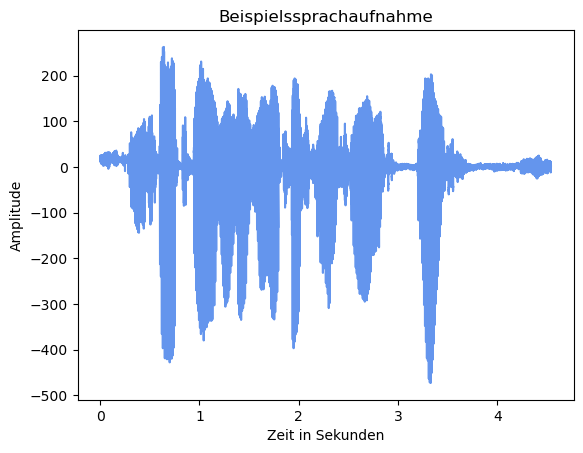

In [4]:
SAMPLE_FILE = "./versuch3-2/test0.npy"

audio = np.load(SAMPLE_FILE)
audio = audio[20000:]
k = np.arange(audio.size)
samples = 44100
k = k / samples
plt.plot(k,audio, color="cornflowerblue")
plt.xlabel("Zeit in Sekunden")
plt.ylabel("Amplitude")
plt.title("Beispielssprachaufnahme")
plt.show()


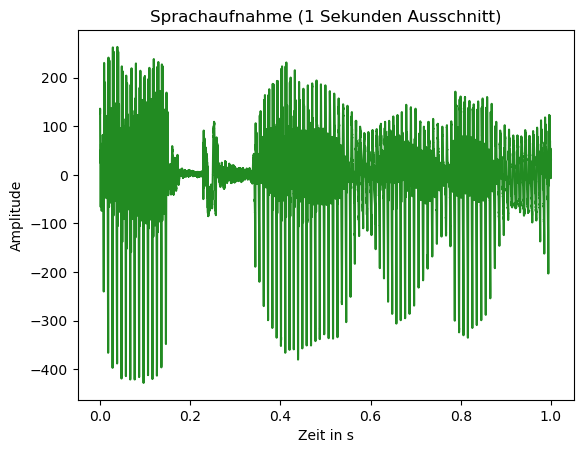

In [5]:
def skip_first(arr, grenzw) :
    for a in range(arr.size):
        if arr[a] >= grenzw: return a

idx_start = skip_first(audio, 125)
idx_end = idx_start + samples
audio_range = audio[idx_start:idx_end]
second = np.arange(samples) / samples

plt.plot(second, audio_range, color="forestgreen")
plt.xlabel('Zeit in s')
plt.ylabel('Amplitude')
plt.title('Sprachaufnahme (1 Sekunden Ausschnitt)')
plt.show()



Grundfrequenz: 207


Text(0.5, 1.0, 'FFT des Test-Signals')

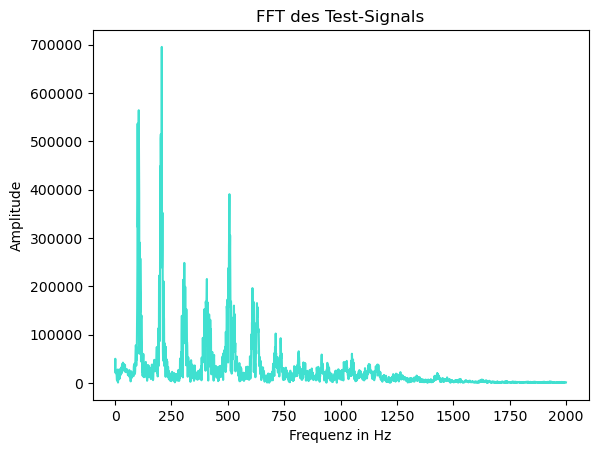

In [6]:
# c.
fft = np.abs(np.fft.fft(audio_range))
p_end = 2000
plt.plot(fft[0:p_end], color="turquoise")
freq = np.argmax(fft[0:(samples // 2)])
print(f"Grundfrequenz: {freq}")
plt.ylabel("Amplitude")
plt.xlabel("Frequenz in Hz")
plt.title("FFT des Test-Signals")

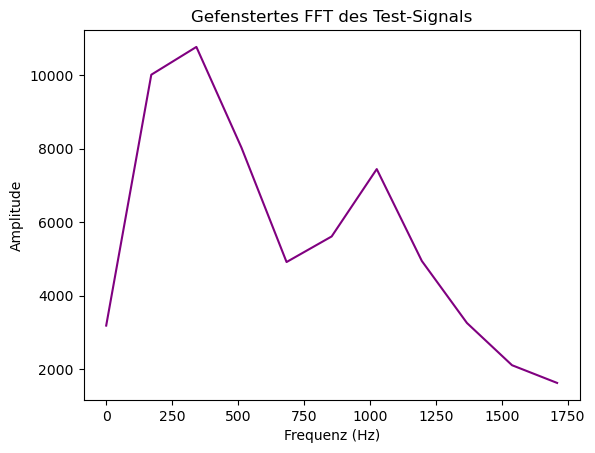

In [7]:
# d. Windowing
w_len = 512
std = w_len // 4 # Fenster entspricht 4 Standardabweichungen
overlap = w_len // 2

weight = windows.gaussian(w_len, std)

ws = (samples // overlap) - 1
windowed = np.zeros((ws, w_len), dtype=float)
fftwin = np.zeros((ws, w_len), dtype=float)
midwin = np.zeros(w_len, dtype=float)

for i in range(ws):
    w_start = i * overlap
    windowed[i] = audio_range[w_start:w_start + w_len] * weight
    fftwin[i] = np.abs(np.fft.fft(windowed[i])) ** 2
    midwin += fftwin[i]

midwin = np.sqrt(midwin / ws)
p_end_idx = p_end // ws

plt.plot((np.arange(w_len) * ws)[0:p_end_idx], midwin[0:p_end_idx], color="purple")
plt.ylabel("Amplitude")
plt.xlabel("Frequenz (Hz)")
plt.title("Gefenstertes FFT des Test-Signals")
plt.show()

## Aufgabe 3: Spracherkennung

In [8]:
# a)

GRENZ = 20
def get_files(x):
    time = samples * 5 # 5s rec time
    file = np.full((5, samples), 0, dtype=float)
    for i in range(0, 5):
        f = np.load(f"./versuch3-3/{x}{i}.npy")[20000:]
        start_idx = skip_first(f, GRENZ)
        file[i] = f[start_idx : start_idx + samples]
    return file

hoch = get_files("hoch")
tief = get_files("tief")
links = get_files("links")
rechts = get_files("rechts")

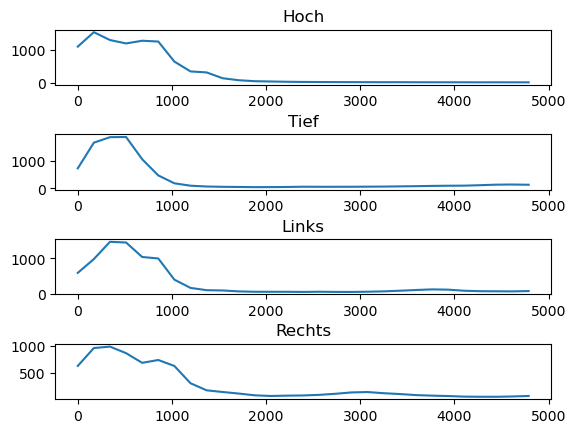

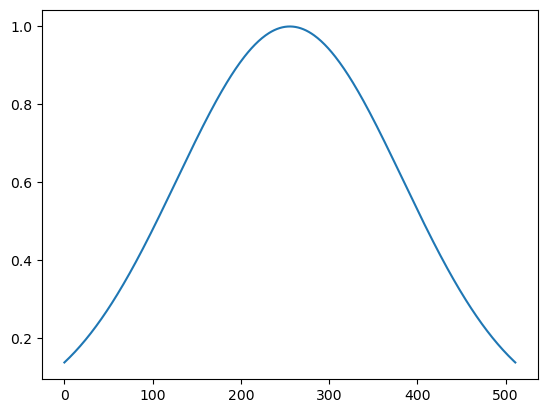

In [9]:
def window_fft(arr):
    mid_fft = 0
    for win_idx in range(0, ws):
        win_start = win_idx * overlap
        windowed = arr[win_start : win_start + w_len] * weight
        fft_arr = np.abs(np.fft.fft(windowed)) ** 2
        mid_fft += fft_arr
    return np.sqrt(mid_fft / ws)

def mean_window_fft(input):
    input_fft = np.zeros((input.shape[0], w_len), dtype=float)
    for i in np.arange(input.shape[0]):
        input_fft[i] = window_fft(input[i])
    return np.mean(input_fft, axis=0)

fig, axs = plt.subplots(4)

ffts = {"Hoch": mean_window_fft(hoch), "Tief": mean_window_fft(tief), "Links": mean_window_fft(links), "Rechts": mean_window_fft(rechts)}
rrange = np.arange(5000 // ws)
x = rrange * ws

idx = 0
for key, value in ffts.items():
    axs[idx].plot(x, value[rrange])
    axs[idx].set_title(key)
    idx += 1

plt.subplots_adjust(hspace=0.9)
plt.show()
plt.plot(weight)
plt.show()

In [10]:
def corrcoeff(f, g):
    s_fg = 0
    s_f = 0
    s_g = 0
    mean_f = np.mean(f, axis=0)
    mean_g = np.mean(g, axis=0)
    for i in np.arange(f.size):
        s_f += (f[i] - mean_f) ** 2
        s_g += (g[i] - mean_g) ** 2
        s_fg += (f[i] - mean_f) * (g[i] - mean_g)
    s_g /= g.size - 1
    s_f /= f.size - 1
    s_fg /= f.size
    return s_fg / np.sqrt(s_f * s_g)
print(f"Korrelation Hoch - Hoch: {corrcoeff(ffts.get("Hoch"), ffts.get("Hoch")):0.4f}")
print(f"Korrelation Hoch - Tief: {corrcoeff(ffts.get("Hoch"), ffts.get("Tief")):0.4f}")

Korrelation Hoch - Hoch: 0.9980
Korrelation Hoch - Tief: 0.8969


Spracherkennung vom Sprecher 1 erfolgreich: 95.0%
Spracherkennung vom Sprecher 2 erfolgreich: 65.0%


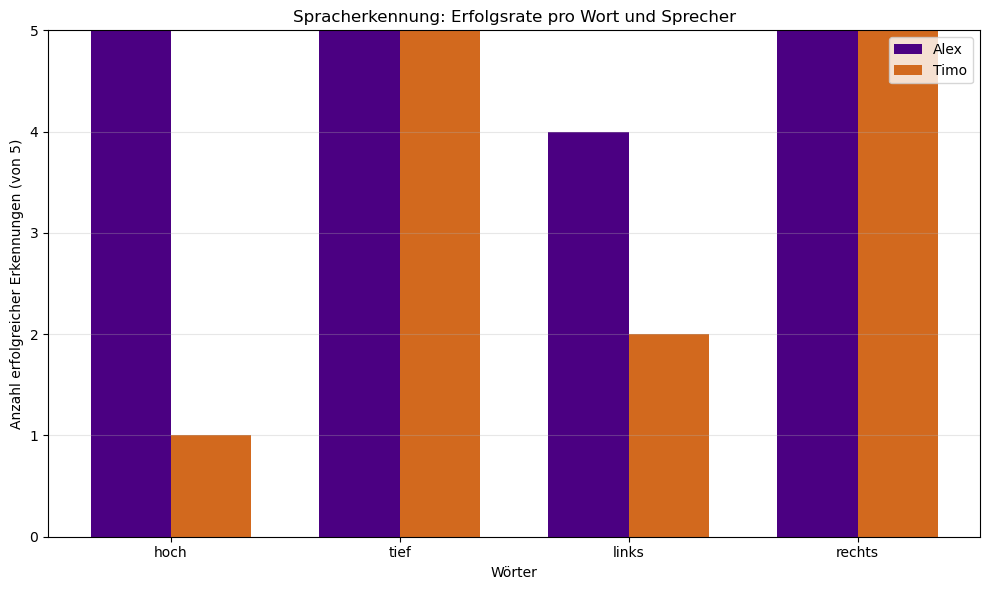

In [11]:
# 3. d)
def greater(a, b, c, d): return max([a,b,c,d]) is a
cmds = list(ffts.keys())
cmds = [cmd.lower() for cmd in cmds]

def word(arr):
    idx = skip_first(arr[20000:], GRENZ)
    arr = arr[idx:idx+samples]
    fft = window_fft(arr)
    rlth = np.zeros(4)
    idxx = 0
    for value in ffts.values():
        rlth[idxx] = corrcoeff(fft, value) # h, t, l, r
        idxx += 1

    if greater(rlth[0], rlth[1], rlth[2], rlth[3]):  return cmds[0]
    elif greater(rlth[1], rlth[2], rlth[3], rlth[0]): return cmds[1]
    elif greater(rlth[2], rlth[3], rlth[0], rlth[1]): return cmds[2]
    elif greater(rlth[3], rlth[0], rlth[1], rlth[2]): return cmds[3]
    else: return "none"

counts = np.zeros(2)
word_counts = np.zeros((2, 4))  # 2 Sprecher, 4 Wörter

BLUE = "\u001b[1;34m"
RESET = "\u001b[0m"
MAGENTA = "\u001b[1;35m"
COLORS = [BLUE, MAGENTA]

for i in range(1,3):
    for j in range(5):
        for k_idx, k in enumerate(cmds):
            h = np.load(f"./versuch3-3/s{i}_{k}{j}.npy")
            if word(h) == k:
                counts[i-1] += 1
                word_counts[i-1, k_idx] += 1


    print(f"Spracherkennung vom {COLORS[i-1]}Sprecher {i}{RESET} erfolgreich: {COLORS[i-1]}{counts[i-1] * 100 / 20}%{RESET}")

# Plot der Erkennungsrate pro Wort
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cmds))
width = 0.35

bars1 = ax.bar(x - width/2, word_counts[0], width, label='Alex', color='indigo')
bars2 = ax.bar(x + width/2, word_counts[1], width, label='Timo', color='chocolate')

ax.set_xlabel('Wörter')
ax.set_ylabel('Anzahl erfolgreicher Erkennungen (von 5)')
ax.set_title('Spracherkennung: Erfolgsrate pro Wort und Sprecher')
ax.set_xticks(x)
ax.set_xticklabels(cmds)
ax.set_ylim(0, 5)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()